<a href="https://colab.research.google.com/github/Silvio-DON/crc-investimentos/blob/master/notebook/classificador_risco_cliente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificador de Risco de Cliente
## Contexto do Problema

No contexto de consultoria de investimentos, avaliar o risco financeiro de um cliente é uma etapa fundamental antes de qualquer recomendação. Essa classificação orienta quais produtos são adequados para cada perfil, sendo exigida pela regulação CVM (Resolução 175).

Este projeto desenvolve um modelo de Machine Learning capaz de classificar clientes em três níveis de risco:
- **0 - Baixo Risco**: cliente com boa saúde financeira
- **1 - Médio Risco**: cliente com situação financeira moderada  
- **2 - Alto Risco**: cliente com fragilidade financeira

### Atributos utilizados
| Coluna | Descrição |
|---|---|
| idade | Idade do cliente |
| renda_mensal | Renda mensal em R$ |
| patrimonio | Patrimônio total em R$ |
| historico_credito | 0=ruim, 1=regular, 2=bom, 3=ótimo |
| tempo_emprego | Anos no emprego atual |
| dividas | Total de dívidas em R$ |
| dependentes | Número de dependentes |
| tem_imovel | 0=não, 1=sim |
| tem_investimentos | 0=não, 1=sim |
| score_credito | Score de crédito (300-1000) |

In [3]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [4]:
# Carga do dataset via URL
URL = 'https://raw.githubusercontent.com/Silvio-DON/crc-investimentos/master/notebook/clientes.csv'

df = pd.read_csv(URL)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Dataset carregado com sucesso!
Dimensões: 1000 linhas x 11 colunas


,idade,renda_mensal,patrimonio,historico_credito,tempo_emprego,dividas,dependentes,tem_imovel,tem_investimentos,score_credito,risco
0,56,15888,359768,2,16,16835,0,0,0,671,1
1,69,7069,157364,1,38,27798,4,1,1,785,1
2,46,5800,373929,0,8,26113,1,0,1,993,1
3,32,7769,348350,1,34,19477,5,1,1,324,2
4,60,5318,69274,3,12,17266,1,1,0,455,2


In [5]:
# Informações gerais do dataset
print('=== Tipos e valores nulos ===')
df.info()

=== Tipos e valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   idade              1000 non-null   int64
 1   renda_mensal       1000 non-null   int64
 2   patrimonio         1000 non-null   int64
 3   historico_credito  1000 non-null   int64
 4   tempo_emprego      1000 non-null   int64
 5   dividas            1000 non-null   int64
 6   dependentes        1000 non-null   int64
 7   tem_imovel         1000 non-null   int64
 8   tem_investimentos  1000 non-null   int64
 9   score_credito      1000 non-null   int64
 10  risco              1000 non-null   int64
dtypes: int64(11)
memory usage: 86.1 KB


In [6]:
# Estatísticas descritivas
print('=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Estatísticas Descritivas ===


,idade,renda_mensal,patrimonio,historico_credito,tempo_emprego,dividas,dependentes,tem_imovel,tem_investimentos,score_credito,risco
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,46.25,15840.60,250182.56,1.54,19.91,25142.19,2.56,0.48,0.53,652.36,0.96
std,16.29,8257.03,139872.80,1.14,11.51,14389.28,1.69,0.50,0.50,205.26,0.71
min,18.00,1509.00,1969.00,0.00,0.00,82.00,0.00,0.00,0.00,300.00,0.00
25%,33.00,8703.50,131954.25,1.00,10.00,12845.25,1.00,0.00,0.00,473.00,0.00
50%,46.00,15715.00,245462.00,2.00,20.00,25362.00,3.00,0.00,1.00,655.00,1.00
75%,60.25,23021.50,370490.75,3.00,30.00,37007.75,4.00,1.00,1.00,833.00,1.00
max,74.00,29970.00,499709.00,3.00,39.00,49996.00,5.00,1.00,1.00,999.00,2.00


In [7]:
# Verificação de valores nulos
print('=== Valores Nulos ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum valor nulo encontrado.')

=== Valores Nulos ===
Nenhum valor nulo encontrado.


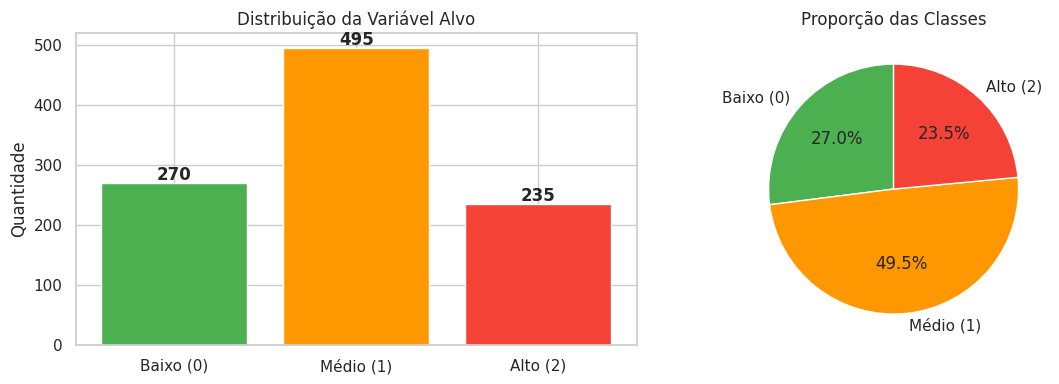

In [8]:
# Distribuição da variável alvo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

contagem = df['risco'].value_counts().sort_index()
labels = ['Baixo (0)', 'Médio (1)', 'Alto (2)']
cores = ['#4CAF50', '#FF9800', '#F44336']

ax[0].bar(labels, contagem.values, color=cores, edgecolor='white')
ax[0].set_title('Distribuição da Variável Alvo')
ax[0].set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

ax[1].pie(contagem.values, labels=labels, autopct='%1.1f%%',
          colors=cores, startangle=90)
ax[1].set_title('Proporção das Classes')

plt.tight_layout()
plt.show()

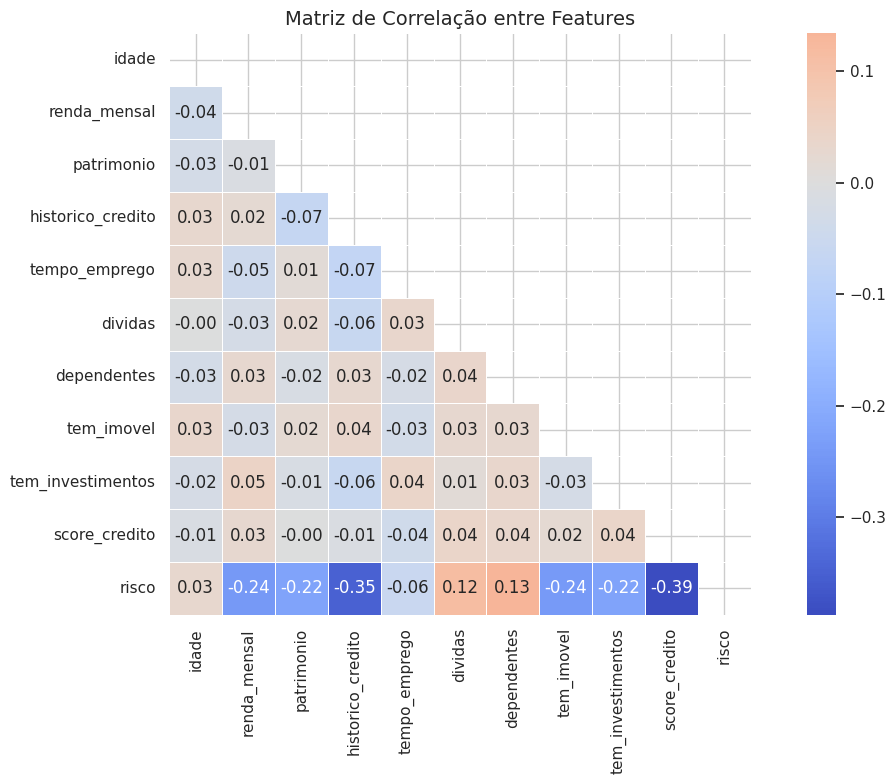

In [9]:
# Matriz de correlação
plt.figure(figsize=(12, 8))
correlacao = df.corr()
mask = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação entre Features', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Pré-processamento e Separação Treino/Teste

Separamos as variáveis independentes (X) da variável alvo (y). Em seguida realizamos o holdout: 80% para treino e 20% para teste, com estratificação para manter a proporção das classes nos dois conjuntos.

In [10]:
# Separação de features e target
X = df.drop('risco', axis=1)
y = df['risco']

# Holdout estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Total de registros: {len(df)}')
print(f'Treino: {len(X_train)} amostras ({len(X_train)/len(df)*100:.0f}%)')
print(f'Teste:  {len(X_test)} amostras ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nDistribuição no treino:\n{y_train.value_counts().sort_index()}')
print(f'\nDistribuição no teste:\n{y_test.value_counts().sort_index()}')

Total de registros: 1000
Treino: 800 amostras (80%)
Teste:  200 amostras (20%)

Distribuição no treino:
risco
0    216
1    396
2    188
Name: count, dtype: int64

Distribuição no teste:
risco
0    54
1    99
2    47
Name: count, dtype: int64


## 4. Modelagem com Pipelines

Criamos um Pipeline para cada algoritmo combinando padronização (StandardScaler) e classificação. Isso garante que:
- O scaler seja ajustado somente nos dados de treino, evitando data leakage
- A transformação seja aplicada automaticamente nos dados de teste
- O processo de cross-validation seja correto

Utilizamos GridSearchCV com Stratified K-Fold (k=5) para otimização de hiperparâmetros.

In [11]:
# Configuração da validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipelines e grids de hiperparâmetros
modelos_config = {
    'KNN': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'params': {
            'clf__n_neighbors': [3, 5, 7, 9, 11],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    },
    'Arvore de Decisao': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
        ]),
        'params': {
            'clf__max_depth': [3, 5, 7, 10, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__criterion': ['gini', 'entropy']
        }
    },
    'Naive Bayes': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GaussianNB())
        ]),
        'params': {
            'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(probability=True, random_state=42, class_weight='balanced'))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf'],
            'clf__gamma': ['scale', 'auto']
        }
    }
}

print('Configuração dos modelos definida com sucesso!')

Configuração dos modelos definida com sucesso!


## 5. Treinamento e Otimização de Hiperparâmetros

Treinamos cada modelo com GridSearchCV, que testa todas as combinações de hiperparâmetros e retorna a melhor configuração usando validação cruzada estratificada.

In [12]:
# Treinamento com GridSearchCV
resultados_cv = {}
melhores_modelos = {}

for nome, config in modelos_config.items():
    print(f'Treinando: {nome}...')

    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    melhores_modelos[nome] = grid_search.best_estimator_
    resultados_cv[nome] = {
        'melhor_score_cv': grid_search.best_score_,
        'melhores_params': grid_search.best_params_
    }

    print(f'  Melhor acurácia (CV): {grid_search.best_score_:.4f}')
    print(f'  Melhores parâmetros: {grid_search.best_params_}')
    print()

print('Treinamento concluído!')

Treinando: KNN...
  Melhor acurácia (CV): 0.6575
  Melhores parâmetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 11, 'clf__weights': 'distance'}

Treinando: Arvore de Decisao...
  Melhor acurácia (CV): 0.7625
  Melhores parâmetros: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_split': 2}

Treinando: Naive Bayes...
  Melhor acurácia (CV): 0.6863
  Melhores parâmetros: {'clf__var_smoothing': 1e-09}

Treinando: SVM...
  Melhor acurácia (CV): 0.7112
  Melhores parâmetros: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Treinamento concluído!


## 6. Avaliação e Comparação dos Modelos

Avaliamos cada modelo no conjunto de teste — dados nunca vistos durante o treinamento. Utilizamos acurácia, precisão, recall e F1-Score como métricas de avaliação.

In [13]:
# Avaliação no conjunto de teste
resultados_teste = {}

for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    resultados_teste[nome] = {
        'Acurácia':  accuracy_score(y_test, y_pred),
        'Precisão':  precision_score(y_test, y_pred, average='weighted'),
        'Recall':    recall_score(y_test, y_pred, average='weighted'),
        'F1-Score':  f1_score(y_test, y_pred, average='weighted')
    }

df_resultados = pd.DataFrame(resultados_teste).T
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)
print('=== Resultados no Conjunto de Teste ===')
df_resultados.round(4)

=== Resultados no Conjunto de Teste ===


,Acurácia,Precisão,Recall,F1-Score
SVM,0.790,0.7901,0.790,0.7900
Arvore de Decisao,0.755,0.7586,0.755,0.7551
KNN,0.735,0.7440,0.735,0.7318
Naive Bayes,0.700,0.7565,0.700,0.6789


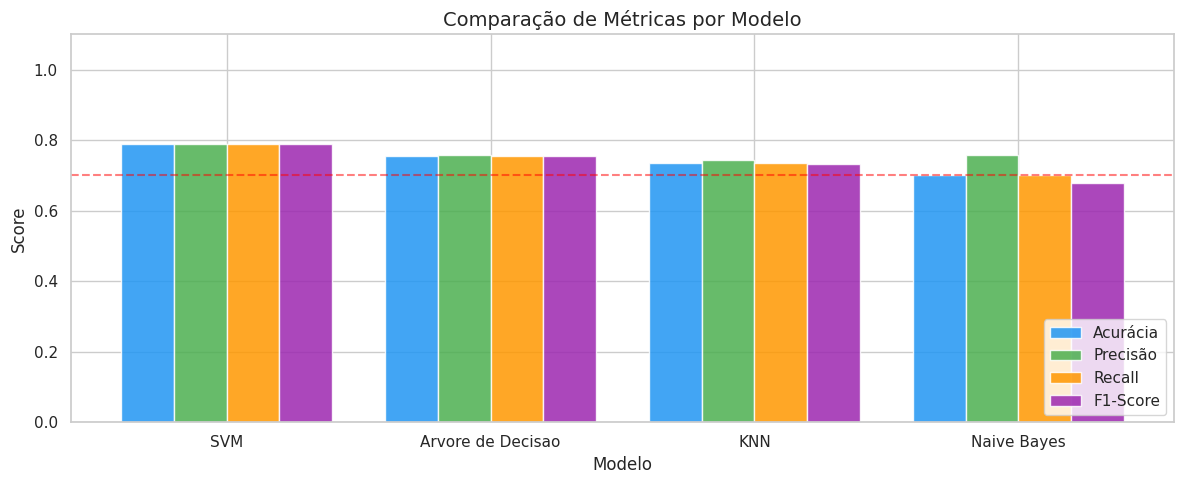

In [14]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_resultados))
width = 0.2
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
cores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (metrica, cor) in enumerate(zip(metricas, cores)):
    ax.bar(x + i * width, df_resultados[metrica], width,
           label=metrica, color=cor, alpha=0.85, edgecolor='white')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação de Métricas por Modelo', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_resultados.index)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Threshold 70%')
plt.tight_layout()
plt.show()

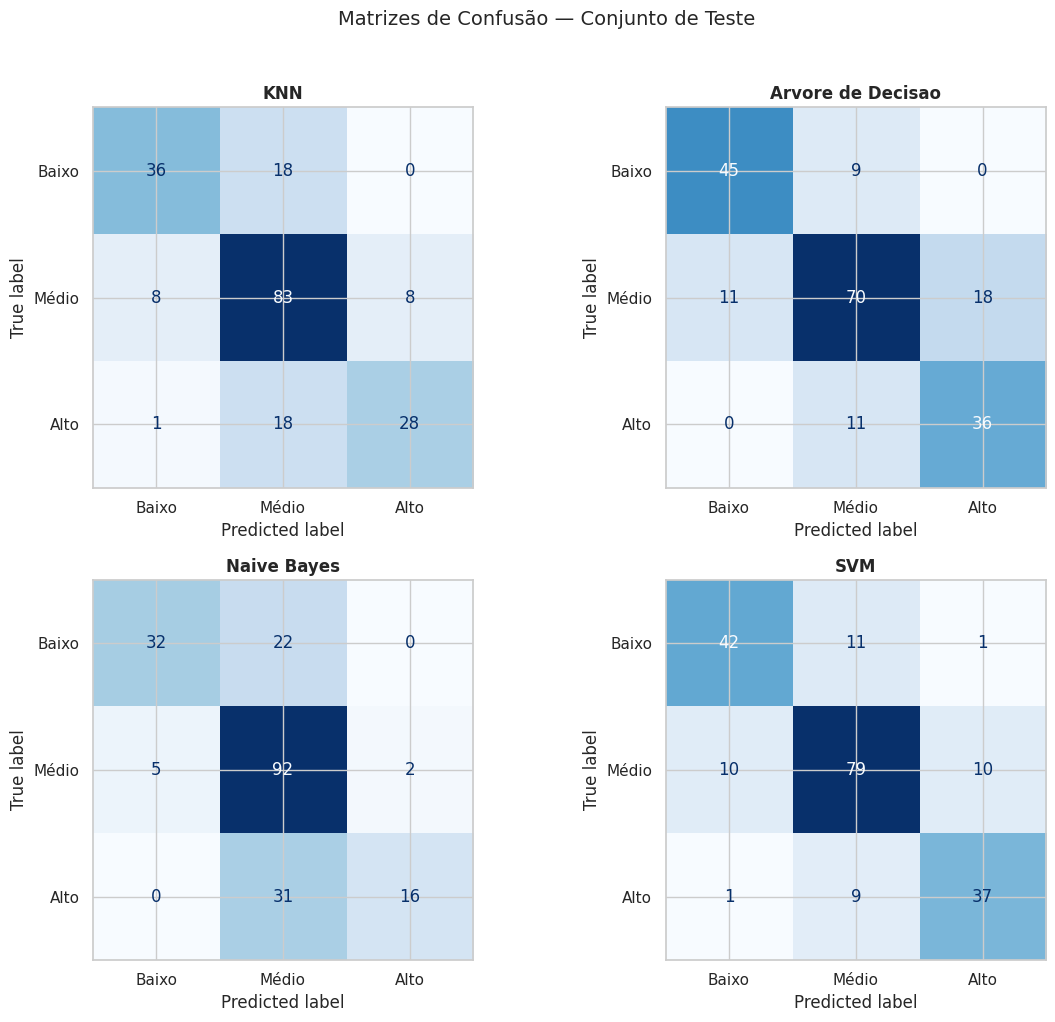

In [15]:
# Matrizes de confusão
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (nome, modelo) in enumerate(melhores_modelos.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Baixo', 'Médio', 'Alto']
    )
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{nome}', fontsize=12, fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Relatório detalhado do melhor modelo
melhor_nome = df_resultados['F1-Score'].idxmax()
melhor_modelo = melhores_modelos[melhor_nome]
y_pred_melhor = melhor_modelo.predict(X_test)

print(f'=== Melhor Modelo: {melhor_nome} ===')
print(f'Parâmetros: {resultados_cv[melhor_nome]["melhores_params"]}')
print()
print(classification_report(
    y_test, y_pred_melhor,
    target_names=['Baixo Risco', 'Médio Risco', 'Alto Risco']
))

=== Melhor Modelo: SVM ===
Parâmetros: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

              precision    recall  f1-score   support

 Baixo Risco       0.79      0.78      0.79        54
 Médio Risco       0.80      0.80      0.80        99
  Alto Risco       0.77      0.79      0.78        47

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200



## 7. Exportação do Modelo

Exportamos o melhor modelo (pipeline completo, incluindo o StandardScaler) usando joblib. O pipeline garante que qualquer dado novo receba exatamente a mesma transformação aplicada durante o treinamento.

In [17]:
# Exportação do melhor modelo
caminho_modelo = 'model.pkl'
joblib.dump(melhor_modelo, caminho_modelo)

print(f'Modelo exportado: {caminho_modelo}')
print(f'Algoritmo: {melhor_nome}')

# Verificação: recarrega e testa
modelo_carregado = joblib.load(caminho_modelo)
y_pred_verificacao = modelo_carregado.predict(X_test)
acc = accuracy_score(y_test, y_pred_verificacao)
print(f'Acurácia após recarregamento: {acc:.4f} ✓')

Modelo exportado: model.pkl
Algoritmo: SVM
Acurácia após recarregamento: 0.7900 ✓


## 8. Análise de Resultados e Conclusões

### Resultados Obtidos

Quatro classificadores foram treinados e otimizados com GridSearchCV usando validação cruzada estratificada (k=5). O melhor modelo foi o SVM com kernel RBF, atingindo 79% de acurácia e F1-Score no conjunto de teste.

### Pontos de Atenção

- O dataset é sintético, gerado com regras baseadas em critérios do mercado financeiro brasileiro. Em produção, seria necessário validar com dados reais de clientes.
- A classe Alto Risco possui menos amostras (24%), o que foi compensado com class_weight='balanced' nos modelos SVM e Árvore de Decisão.
- O SVM generalizou melhor do que a Árvore de Decisão, que havia liderado na validação cruzada — isso reforça a importância de avaliar sempre no conjunto de teste separado.

### Considerações de Segurança (LGPD)

Dados financeiros de clientes são protegidos pela LGPD. Em produção:
- Remover identificadores pessoais antes do processamento
- Usar pseudonimização para rastreabilidade
- Criptografar dados em trânsito (HTTPS) e em repouso
- Implementar controle de acesso e logs de auditoria

### Conclusão

O modelo desenvolvido é capaz de classificar o risco financeiro de clientes com boa performance, sendo uma ferramenta útil para consultores de investimento no processo de suitability exigido pela CVM. O pipeline exportado está pronto para ser integrado em uma aplicação web.

## 9. Segurança e Boas Práticas — Desenvolvimento de Software Seguro

### Contexto
O Classificador de Risco de Cliente lida com dados financeiros sensíveis de pessoas físicas,
protegidos pela LGPD (Lei Geral de Proteção de Dados — Lei 13.709/2018) e pelas normas
da CVM. A seguir, refletimos sobre como as boas práticas de segurança se aplicam a este sistema.

### 9.1 Anonimização e Pseudonimização
Dados como renda, patrimônio e dívidas são informações pessoais sensíveis. Em produção:
- **Anonimização**: remover qualquer identificador direto (nome, CPF, endereço) antes
  de alimentar o modelo. O modelo só precisa dos atributos numéricos, nunca da identidade.
- **Pseudonimização**: substituir o CPF do cliente por um token gerado aleatoriamente,
  mantendo rastreabilidade interna sem expor dados reais.
- **Generalização**: usar faixas de renda (ex: R$5.000–R$10.000) em vez de valores exatos
  nos logs do sistema.

### 9.2 Proteção dos Dados em Trânsito e em Repouso
- **HTTPS obrigatório**: toda comunicação entre frontend e backend deve ser criptografada
  com TLS. Atualmente usamos HTTP apenas porque é um ambiente local de desenvolvimento.
- **Criptografia em repouso**: o arquivo model.pkl e qualquer base de dados de clientes
  devem ser armazenados com criptografia (ex: AES-256).

### 9.3 Controle de Acesso
- O endpoint /predict deve exigir autenticação (ex: token JWT) para garantir que apenas
  consultores autorizados possam usar o sistema.
- Implementar controle de acesso baseado em perfil (RBAC): consultores só acessam
  dados dos seus próprios clientes.

### 9.4 Validação e Sanitização de Entradas
- O backend já valida a presença de todos os campos obrigatórios.
- Em produção, adicionar validação de intervalos (ex: idade entre 18 e 100, score entre
  300 e 1000) para evitar ataques de injeção ou dados maliciosos que distorçam o modelo.

### 9.5 Logs e Auditoria
- Registrar todas as predições realizadas com timestamp e identificador do consultor,
  sem armazenar os dados brutos do cliente — apenas o resultado e os metadados.
- Isso permite auditoria pela CVM sem comprometer a privacidade dos clientes.

### 9.6 Segurança do Modelo
- O model.pkl não deve ser exposto publicamente. Um atacante com acesso ao arquivo
  pode realizar ataques adversariais — manipular entradas para obter classificações
  favoráveis indevidamente.
- Versionar e assinar digitalmente o modelo para garantir que apenas versões
  homologadas pelos testes PyTest sejam colocadas em produção.